# Assignment 2 — Part I: Data Generation

**2AMS11 Survival Analysis for Data Scientists** · Q1 2026

## 1. Practical context

A hypothetical cohort of **≈800 adult women** who have completed treatment for breast cancer,
followed for a maximum of **five years**. The event of interest is the **first confirmed breast
cancer recurrence after completion of treatment**.

At the start of follow-up, routinely recorded demographic, tumour and treatment characteristics are
available; three of them enter the survival model (Section 3). Not every patient recurs: some remain
recurrence-free until the study ends, others leave before five years. In both cases the exact
recurrence time is unobserved and the patient is **right-censored**. Survival analysis is
appropriate precisely because it lets censored and observed times both contribute.

**Research question.** *How accurately can a parametric survival model estimate the probability of
breast cancer recurrence over time based on routinely recorded patient and clinical
characteristics?*

Because the data-generating mechanism (DGM) below fixes the true recurrence-time distribution and
the true covariate effects, every fitted model can later be scored against known values.

**What this notebook does.** Implements and validates the DGM: generate covariates → generate
recurrence times → apply censoring → check calibration, Kaplan–Meier fit, hazard shape and
parameter recovery → preview the two misspecified analyses → export.

> **Time is measured in years throughout**, so the administrative cut-off is $\tau = 5$.

In [14]:
import json
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter
from scipy.optimize import minimize
from scipy.stats import truncnorm

plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (6.5, 4.0),
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 9})

SEED = 2026
rng = np.random.default_rng(SEED)

## 2. Survival model

Recurrence times are generated from a **Weibull proportional-hazards (PH)** model:

$$
h(t \mid \mathbf{x}) \;=\; \underbrace{\lambda\,\gamma\,t^{\gamma-1}}_{\text{baseline } h_0(t)}\,
e^{\mathbf{x}^{\top}\beta},
\qquad
S(t \mid \mathbf{x}) = \exp\!\big\{-\lambda t^{\gamma} e^{\mathbf{x}^{\top}\beta}\big\},
\qquad \lambda, \gamma > 0 .
$$

**Why Weibull.** It is the only distribution that is simultaneously proportional-hazards *and*
accelerated-failure-time, it has a closed-form survival function (so inversion sampling is exact and
cheap), and — unlike the exponential — its shape parameter lets the recurrence hazard change over
time. Since the research question is about estimating $S(t\mid\mathbf{x})$ *over time*, the model
must be able to represent a non-constant hazard.

**Shape $\gamma = 1.6 > 1 \Rightarrow$ an increasing baseline hazard.** Recurrence risk is low
immediately after successful treatment and builds up over the following years as residual
micro-metastatic disease grows to a detectable size.

> **Modelling caveat (worth one line in your Limitations section).** The observed breast cancer
> recurrence hazard is in reality *peaked* — it rises to a maximum around year 2 and then declines.
> A Weibull hazard is **monotone**, so it cannot reproduce that peak. Over a 5-year window the
> increasing branch is the dominant feature, which is what $\gamma = 1.6$ captures.

**The scale $\lambda$ is not chosen directly.** We fix a clinically interpretable target instead:
the *reference patient* (mean age, mean tumour size, no chemotherapy) has a 5-year recurrence
probability $p_0 = 0.25$. Then

$$
S_0(\tau) = 1 - p_0 = \exp(-\lambda \tau^{\gamma})
\quad\Longrightarrow\quad
\lambda = \frac{-\log(1-p_0)}{\tau^{\gamma}} \approx 0.0219, \qquad \tau = 5 .
$$

**Inversion sampling.** Since $S(T \mid \mathbf{x}) \sim \mathrm{Unif}(0,1)$, drawing $U$ and solving
$S(T\mid\mathbf{x}) = U$ gives

$$
T_i \;=\; \left[\frac{-\log U_i}{\lambda\, e^{\mathbf{x}_i^{\top}\beta}}\right]^{1/\gamma},
\qquad U_i \sim \mathrm{Unif}(0,1).
$$

In [15]:
@dataclass(frozen=True)
class DGP:
    '''All true parameters of the data-generating process. Time is in YEARS.'''

    # --- Weibull baseline hazard -------------------------------------------------
    gamma: float = 1.60        # shape; > 1 => recurrence hazard increases over time
    p0_tau: float = 0.25       # 5-year recurrence prob. for the reference patient
    tau: float = 5.0           # administrative censoring time (years)

    # --- x1: age at start of follow-up (years) -----------------------------------
    age_mean: float = 60.0
    age_sd: float = 12.0
    age_lo: float = 30.0
    age_hi: float = 85.0

    # --- x2: tumour size at diagnosis (mm) ---------------------------------------
    size_mean: float = 30.0
    size_sd: float = 8.0
    size_lo: float = 5.0
    size_hi: float = 60.0

    # --- x3: chemotherapy, allocated by indication (NOT randomised) --------------
    chemo_intercept: float = -2.00   # logit P(chemo) = a + b * tumour_size
    chemo_size_slope: float = 0.06

    # --- true log hazard ratios --------------------------------------------------
    beta_age: float = -0.15    # per +10 years   (HR 0.86) - younger age is adverse
    beta_size: float = 0.03    # per +1 mm       (HR 1.03/mm, 1.35 per 10 mm)
    beta_chemo: float = -0.50  # chemotherapy    (HR 0.61) - protective

    # --- loss to follow-up -------------------------------------------------------
    dropout_by_tau: float = 0.15   # P(drop out before 5 years)

    @property
    def lam(self) -> float:
        '''Weibull scale implied by the target 5-year risk of the reference patient.'''
        return float(-np.log(1.0 - self.p0_tau) / self.tau ** self.gamma)

    @property
    def dropout_rate(self) -> float:
        '''Exponential dropout rate implied by the target 5-year dropout probability.'''
        return float(-np.log(1.0 - self.dropout_by_tau) / self.tau)

    @property
    def beta(self) -> np.ndarray:
        return np.array([self.beta_age, self.beta_size, self.beta_chemo])


COVARIATES = ["age_c10", "size_c", "chemo"]
N_PATIENTS = 800
dgp = DGP()


def ndict(values, names=None, nd: int = 3) -> dict:
    '''Pair values with covariate names, rounded, for readable printing.'''
    return {n: round(float(v), nd) for n, v in zip(names or COVARIATES, values)}


shape_word = "increasing" if dgp.gamma > 1 else "decreasing"
print(f"gamma (shape)      = {dgp.gamma:.3f}   -> {shape_word} hazard")
print(f"lambda (scale)     = {dgp.lam:.5f} -> S0(5y) = {np.exp(-dgp.lam * dgp.tau**dgp.gamma):.3f}")
print(f"dropout rate       = {dgp.dropout_rate:.5f} per year")
print(f"true beta          = {ndict(dgp.beta)}")
print(f"true hazard ratios = {ndict(np.exp(dgp.beta))}")

gamma (shape)      = 1.600   -> increasing hazard
lambda (scale)     = 0.02191 -> S0(5y) = 0.750
dropout rate       = 0.03250 per year
true beta          = {'age_c10': -0.15, 'size_c': 0.03, 'chemo': -0.5}
true hazard ratios = {'age_c10': 0.861, 'size_c': 1.03, 'chemo': 0.607}


## 3. Covariates

| | Covariate | Distribution | Model coding | True $\beta$ | HR | Expected direction |
|---|---|---|---|---|---|---|
| $x_1$ | Age at start of follow-up (years) | $\mathcal{N}(60, 12^2)$ truncated to $[30, 85]$ | $(\text{age}-60)/10$ | $-0.15$ | 0.86 | younger $\Rightarrow$ higher risk |
| $x_2$ | Tumour size at diagnosis (mm) | $\mathcal{N}(30, 8^2)$ truncated to $[5, 60]$ | $\text{size}-30$ | $+0.03$ | 1.03 per mm | larger $\Rightarrow$ higher risk |
| $x_3$ | Chemotherapy received ($1$/$0$) | $\mathrm{Bernoulli}(p)$, $\operatorname{logit} p = -2.0 + 0.06\,x_2$ | $0/1$ | $-0.50$ | 0.61 | treated $\Rightarrow$ lower risk |

**Age.** Younger age at diagnosis is an established adverse prognostic factor in breast cancer
(more aggressive tumour biology), so the hazard *decreases* with age: $\beta_1 = -0.15$ per decade.
*If your group prefers the opposite convention, flip the sign of `beta_age` — nothing else changes.*

**Tumour size.** Larger primaries carry a higher burden of residual micro-metastatic disease, so the
hazard rises with size. A per-millimetre log-hazard of $0.03$ means a 10 mm larger tumour multiplies
the hazard by $e^{0.3}\approx 1.35$.

**Chemotherapy.** Adjuvant chemotherapy eradicates residual disease and is protective, $HR = 0.61$.

### Relationship among the covariates — confounding by indication

Chemotherapy is **not randomised**. It is allocated by clinical indication, and the strongest
indication is tumour size:

$$
\operatorname{logit}P(x_3 = 1 \mid x_2) = -2.0 + 0.06\,x_2
\quad\Longrightarrow\quad
P(\text{chemo}) \approx 0.15,\ 0.45,\ 0.83 \ \text{at } 5,\ 30,\ 60\ \text{mm}.
$$

This is the single most important structural feature of the DGM. Patients who receive chemotherapy
are systematically **higher risk** to begin with, so a crude comparison of treated vs. untreated
understates the true protective effect: the unadjusted hazard ratio is $\approx 0.68$ against a true
$0.61$, masking roughly **23%** of the benefit. Only a model that adjusts for tumour size recovers
$\beta_3 = -0.50$. This is what makes "omit an important covariate" a genuinely damaging
misspecification in Part II rather than a cosmetic one.

Age is generated independently of tumour size, so it is a predictor but not a confounder here.

In [16]:
def _truncated_normal(n, mean, sd, lo, hi, rng):
    a, b = (lo - mean) / sd, (hi - mean) / sd
    return truncnorm.rvs(a, b, loc=mean, scale=sd, size=n, random_state=rng)


def generate_covariates(n: int, dgp: DGP, rng: np.random.Generator) -> pd.DataFrame:
    '''Draw the three baseline covariates for `n` patients.'''
    age = _truncated_normal(n, dgp.age_mean, dgp.age_sd, dgp.age_lo, dgp.age_hi, rng)
    size = _truncated_normal(n, dgp.size_mean, dgp.size_sd, dgp.size_lo, dgp.size_hi, rng)

    # chemotherapy is allocated by indication -> confounded with tumour size
    logit_p = dgp.chemo_intercept + dgp.chemo_size_slope * size
    p_chemo = 1.0 / (1.0 + np.exp(-logit_p))
    chemo = rng.binomial(1, p_chemo)

    return pd.DataFrame({
        "age": age,
        "tumor_size": size,
        "chemo": chemo,
        "p_chemo": p_chemo,
        "age_c10": (age - dgp.age_mean) / 10.0,
        "size_c": size - dgp.size_mean,
    })


def linear_predictor(df: pd.DataFrame, dgp: DGP) -> np.ndarray:
    '''x'beta on the log-hazard scale.'''
    return df[COVARIATES].to_numpy() @ dgp.beta

## 4. Censoring

Two right-censoring mechanisms act together:

1. **Administrative censoring at $\tau = 5$ years.** Follow-up stops when the study window closes.
   The cut-off is fixed by design and therefore carries no information about a patient's recurrence
   time — censoring is independent by construction.
2. **Loss to follow-up**, $C_i \sim \mathrm{Exp}(\rho)$ with $\rho$ set so that 15% of patients would
   drop out within five years. Patients move, transfer care, or withdraw consent for reasons
   unrelated to their (unobserved) recurrence time.

Both mechanisms are independent of $T_i$ given $\mathbf{x}_i$, so censoring is **non-informative**
and the likelihood in Section 7 is valid. This is an assumption, not a fact: if patients dropped out
*because* they felt unwell, censoring would be informative and estimates would be biased. We
deliberately generate independent censoring so that any bias observed in Part III is attributable to
the misspecification under study rather than to the censoring mechanism.

The observed data are

$$
Y_i = \min(T_i,\, C_i,\, \tau), \qquad \delta_i = \mathbb{1}\{T_i \le \min(C_i, \tau)\}.
$$

## 5. Data-generating mechanism

Putting Sections 2–4 together, one replicate of $n = 800$ patients is generated as:

$$
\begin{aligned}
x_{1i} &\sim \mathcal{N}(60, 12^2)\big|_{[30,85]}, \qquad
x_{2i} \sim \mathcal{N}(30, 8^2)\big|_{[5,60]}, \qquad
x_{3i}\mid x_{2i} \sim \mathrm{Bernoulli}(p_i),\ \operatorname{logit}p_i = -2.0 + 0.06\,x_{2i},\\[2pt]
T_i &= \Bigl[-\log U_i \,\big/\, \lambda e^{\mathbf{x}_i^{\top}\beta}\Bigr]^{1/\gamma},
\qquad U_i \sim \mathrm{Unif}(0,1),
\qquad \lambda = 0.0219,\ \gamma = 1.6,\ \beta = (-0.15,\ 0.03,\ -0.50),\\[2pt]
C_i &\sim \mathrm{Exp}(\rho),\quad \rho = 0.0325,
\qquad Y_i = \min(T_i, C_i, 5), \qquad \delta_i = \mathbb{1}\{T_i \le \min(C_i, 5)\}.
\end{aligned}
$$

with $R = 2000$ replicates per scenario in Part III.

In [17]:
def generate_dataset(n: int = N_PATIENTS, dgp: DGP = dgp,
                     rng: np.random.Generator = None) -> pd.DataFrame:
    '''Simulate one cohort of `n` patients from the Weibull PH model.

    Returns the observed data (`time`, `event`) alongside the latent quantities
    (`T_true`, `C_dropout`, `lp`) that are used for diagnostics only.
    '''
    rng = np.random.default_rng() if rng is None else rng
    df = generate_covariates(n, dgp, rng)
    lp = linear_predictor(df, dgp)

    # --- recurrence times: inversion sampling of the Weibull PH model -------------
    u = rng.uniform(size=n)
    T = (-np.log(u) / (dgp.lam * np.exp(lp))) ** (1.0 / dgp.gamma)

    # --- censoring: loss to follow-up + administrative cut-off at tau -------------
    C = rng.exponential(scale=1.0 / dgp.dropout_rate, size=n)

    df["lp"] = lp
    df["T_true"] = T
    df["C_dropout"] = C
    df["time"] = np.minimum(T, np.minimum(C, dgp.tau))
    df["event"] = ((T <= C) & (T <= dgp.tau)).astype(int)
    df["censor_type"] = np.where(
        df["event"] == 1, "recurrence",
        np.where(C < dgp.tau, "lost to follow-up", "administrative"))
    return df


data = generate_dataset(N_PATIENTS, dgp, rng)
data.head(10)

,age,tumor_size,chemo,p_chemo,age_c10,size_c,lp,T_true,C_dropout,time,event,censor_type
0,49.047743,36.083903,0,0.541165,-1.095226,6.083903,0.346801,6.263168,6.846979,5.000000,0,administrative
1,63.989873,34.089552,1,0.511341,0.398987,4.089552,-0.437162,2.214245,39.477961,2.214245,1,recurrence
2,58.851630,36.311814,1,0.544559,-0.114837,6.311814,-0.293420,17.496420,5.501263,5.000000,0,administrative
3,55.938673,27.762223,1,0.417203,-0.406133,-2.237777,-0.506213,4.987908,10.111730,4.987908,1,recurrence
4,55.451159,22.843464,0,0.347648,-0.454884,-7.156536,-0.146463,5.247674,21.887857,5.000000,0,administrative
5,69.149517,28.690431,1,0.430803,0.914952,-1.309569,-0.676530,9.457784,46.207059,5.000000,0,administrative
6,74.647612,35.167685,1,0.527488,1.464761,5.167685,-0.564684,15.202134,45.060370,5.000000,0,administrative
7,48.977191,38.168615,0,0.572025,-1.102281,8.168615,0.410401,2.508313,6.190257,2.508313,1,recurrence
8,64.391190,40.355484,1,0.603801,0.439119,10.355484,-0.255203,1.448732,11.669721,1.448732,1,recurrence
9,53.607180,49.493982,0,0.725048,-0.639282,19.493982,0.680712,6.910170,5.547257,5.000000,0,administrative


## 6. Sanity checks

### 6.1 Event rate, censoring breakdown, and calibration

In [18]:
def describe_cohort(df: pd.DataFrame) -> None:
    print(f"n                       = {len(df)}")
    print(f"recurrences             = {df['event'].sum()}  ({df['event'].mean():.1%})")
    print(f"censored                = {(1 - df['event']).sum()}  ({1 - df['event'].mean():.1%})")
    print()
    print("censoring breakdown (%):")
    print((df["censor_type"].value_counts(normalize=True) * 100).round(1).to_string())
    print()
    print(f"median follow-up        = {df['time'].median():.2f} years")
    print(f"mean follow-up          = {df['time'].mean():.2f} years")
    late = df.loc[df["event"] == 1, "time"].ge(2.5).mean()
    print(f"recurrences after 2.5 y = {late:.1%} of all events (late-risk build-up)")


describe_cohort(data)

n                       = 800
recurrences             = 150  (18.8%)
censored                = 650  (81.2%)

censoring breakdown (%):
censor_type
administrative       68.0
recurrence           18.8
lost to follow-up    13.2

median follow-up        = 5.00 years
mean follow-up          = 4.27 years
recurrences after 2.5 y = 60.0% of all events (late-risk build-up)


In [19]:
# A large cohort, used only for the diagnostics below.
big = generate_dataset(200_000, dgp, np.random.default_rng(SEED + 1))

# Does the reference patient really carry a 25% 5-year risk?
ref = pd.DataFrame({"age_c10": [0.0], "size_c": [0.0], "chemo": [0]})
S0_tau = float(np.exp(-dgp.lam * dgp.tau ** dgp.gamma * np.exp(linear_predictor(ref, dgp)))[0])

near_ref = (big["age"].between(58, 62) & big["tumor_size"].between(28, 32) & (big["chemo"] == 0))
emp = (big.loc[near_ref, "T_true"] <= dgp.tau).mean()

print(f"theoretical P(T <= 5y | reference patient) = {1 - S0_tau:.4f}   (target {dgp.p0_tau})")
print(f"empirical  P(T <= 5y | near-reference)     = {emp:.4f}   (n = {near_ref.sum():,})")
print()
print(f"marginal P(T <= 5y), censoring ignored     = {(big['T_true'] <= dgp.tau).mean():.1%}")
print(f"observed recurrence rate, n=800 cohort     = {data['event'].mean():.1%}")

theoretical P(T <= 5y | reference patient) = 0.2500   (target 0.25)
empirical  P(T <= 5y | near-reference)     = 0.2391   (n = 2,948)

marginal P(T <= 5y), censoring ignored     = 21.4%
observed recurrence rate, n=800 cohort     = 18.8%


          age  tumor_size   chemo
count  800.00      800.00  800.00
mean    60.54       29.99    0.45
std     10.91        7.82    0.50
min     30.86        8.82    0.00
25%     53.13       24.38    0.00
50%     60.75       29.92    0.00
75%     68.26       35.48    1.00
max     84.94       53.61    1.00

corr(age, tumour size)   = -0.043   (independent by design)
corr(tumour size, chemo) = +0.243   (confounding by indication)
corr(age, chemo)         = -0.079

mean tumour size by treatment group:
        mean   std  count
chemo                    
0      28.28  7.64    441
1      32.10  7.54    359


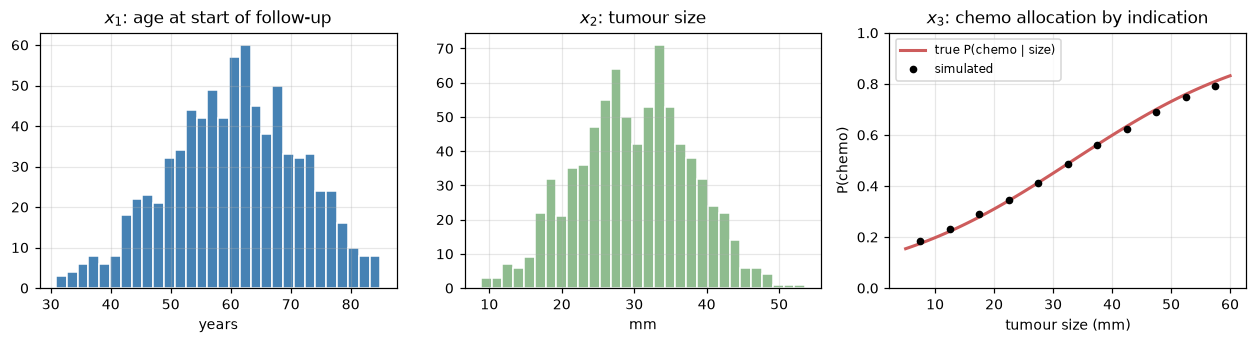

In [20]:
# Covariate distributions and the confounding structure
print(data[["age", "tumor_size", "chemo"]].describe().round(2).to_string())
print()
print(f"corr(age, tumour size)   = {data['age'].corr(data['tumor_size']):+.3f}   (independent by design)")
print(f"corr(tumour size, chemo) = {data['tumor_size'].corr(data['chemo']):+.3f}   (confounding by indication)")
print(f"corr(age, chemo)         = {data['age'].corr(data['chemo']):+.3f}")
print()
print("mean tumour size by treatment group:")
print(data.groupby("chemo")["tumor_size"].agg(["mean", "std", "count"]).round(2).to_string())

fig, ax = plt.subplots(1, 3, figsize=(11.5, 3.2))
ax[0].hist(data["age"], bins=30, color="steelblue", edgecolor="white")
ax[0].set(title="$x_1$: age at start of follow-up", xlabel="years")
ax[1].hist(data["tumor_size"], bins=30, color="darkseagreen", edgecolor="white")
ax[1].set(title="$x_2$: tumour size", xlabel="mm")

size_grid = np.linspace(dgp.size_lo, dgp.size_hi, 100)
ax[2].plot(size_grid, 1 / (1 + np.exp(-(dgp.chemo_intercept + dgp.chemo_size_slope * size_grid))),
           color="indianred", lw=2, label="true P(chemo | size)")
bins = np.arange(5, 65, 5)
grp = big.groupby(pd.cut(big["tumor_size"], bins=bins), observed=True)["chemo"].mean()
ax[2].plot([iv.mid for iv in grp.index], grp.to_numpy(), "o", color="black", ms=4, label="simulated")
ax[2].set(title="$x_3$: chemo allocation by indication", xlabel="tumour size (mm)",
          ylabel="P(chemo)", ylim=(0, 1))
ax[2].legend(fontsize=8)
fig.tight_layout()
plt.show()

### 6.2 Kaplan–Meier versus the true survival curve

The non-parametric KM estimate should lie on top of the analytic $S(t\mid\mathbf{x})$ averaged over
the covariate distribution. If it does, the inversion sampling and censoring logic are correct.

The right-hand panel is the important one. Splitting crudely on chemotherapy, the treated group
*does* show better recurrence-free survival — but by less than it should, because those patients
started with systematically larger tumours. **The dashed truth matches the KM curves, confirming the
generator; but neither curve recovers the causal effect** (crude HR $\approx 0.68$ vs. true $0.61$).
That gap is exactly the confounding the Part II analysis has to adjust away.

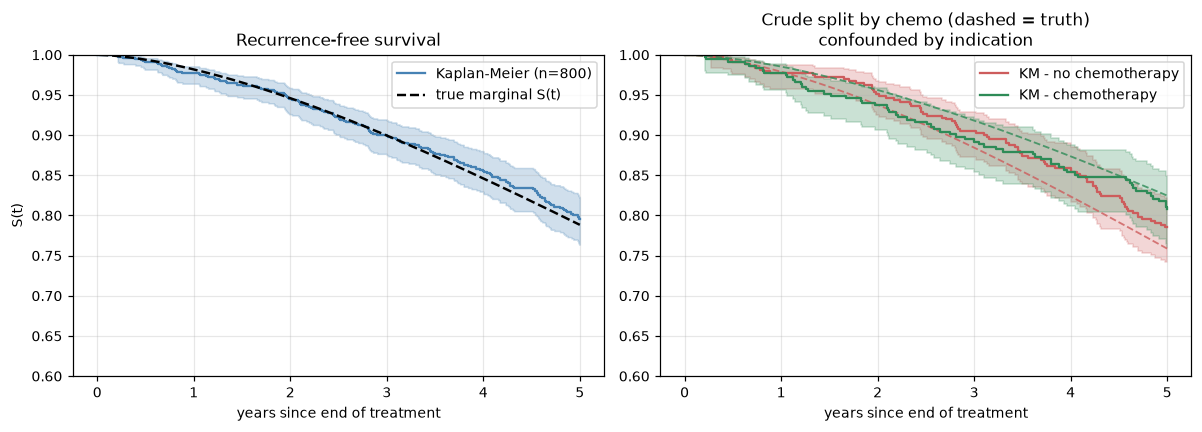

In [21]:
def true_marginal_survival(t_grid: np.ndarray, df: pd.DataFrame, dgp: DGP) -> np.ndarray:
    '''E_x[S(t|x)]: the marginal survival curve implied by the model.'''
    e_lp = np.exp(linear_predictor(df, dgp))[None, :]     # (1, n)
    H = dgp.lam * (t_grid[:, None] ** dgp.gamma) * e_lp   # (n_grid, n)
    return np.exp(-H).mean(axis=1)


t_grid = np.linspace(0.02, dgp.tau, 200)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

KaplanMeierFitter().fit(data["time"], data["event"], label="Kaplan-Meier (n=800)") \
    .plot_survival_function(ax=ax[0], color="steelblue")
ax[0].plot(t_grid, true_marginal_survival(t_grid, data, dgp), "k--", lw=1.6,
           label="true marginal S(t)")
ax[0].set(title="Recurrence-free survival", xlabel="years since end of treatment",
          ylabel="S(t)", ylim=(0.6, 1.0))
ax[0].legend()

for arm, colour, lbl in [(0, "indianred", "no chemotherapy"), (1, "seagreen", "chemotherapy")]:
    sub = data[data["chemo"] == arm]
    KaplanMeierFitter().fit(sub["time"], sub["event"], label=f"KM - {lbl}") \
        .plot_survival_function(ax=ax[1], color=colour)
    ax[1].plot(t_grid, true_marginal_survival(t_grid, sub, dgp), "--", color=colour, lw=1.2, alpha=0.8)
ax[1].set(title="Crude split by chemo (dashed = truth)\nconfounded by indication",
          xlabel="years since end of treatment", ylim=(0.6, 1.0))
fig.tight_layout()
plt.show()

### 6.3 Is the hazard really increasing?

* **Binned empirical hazard.** In each 0.25-year window, estimate
  $\hat h = (\text{events}) / (\text{person-years at risk})$ and compare with the exact *population*
  hazard $h_{\text{pop}}(t) = \mathbb{E}[h(t\mid \mathbf{x})S(t\mid \mathbf{x})]/\mathbb{E}[S(t\mid \mathbf{x})]$.
  $h_{\text{pop}}$ rises more slowly than $h_0$ because high-risk patients are selectively removed
  from the risk set over time (frailty depletion).
* **Weibull log–log plot.** For a Weibull model $\log(-\log S(t)) = \log\lambda + \gamma\log t$, so
  regressing $\log(-\log\hat S(t))$ on $\log t$ must give a slope $\approx \gamma = 1.6$.

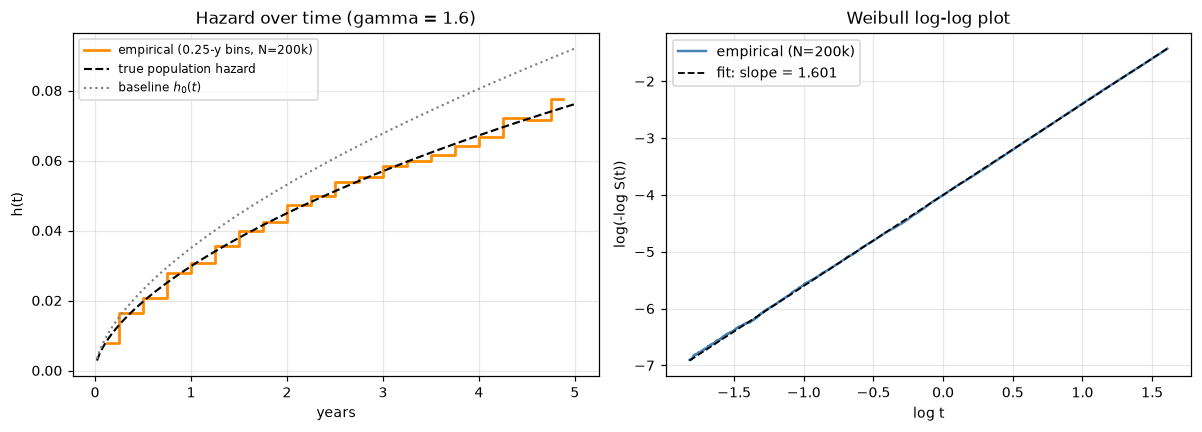

shape from the log-log slope = 1.6010   (true gamma = 1.6)
lambda from the intercept    = 0.01830   (true lambda = 0.02191)

These are close to but not exactly the true values, because this is the *marginal* curve,
which mixes over the covariate distribution. Marginal Weibull parameters are not the
conditional ones (non-collapsibility); the likelihood fit below conditions on x and
recovers the truth exactly.


In [22]:
def empirical_hazard(df: pd.DataFrame, bins: np.ndarray) -> np.ndarray:
    '''Events divided by person-years at risk within each [lo, hi) window.'''
    t, d = df["time"].to_numpy(), df["event"].to_numpy()
    out = []
    for lo, hi in zip(bins[:-1], bins[1:]):
        person_years = np.clip(np.minimum(t, hi) - lo, 0.0, None).sum()
        n_events = np.count_nonzero((t >= lo) & (t < hi) & (d == 1))
        out.append(n_events / person_years if person_years > 0 else np.nan)
    return np.array(out)


def true_population_hazard(t_grid: np.ndarray, df: pd.DataFrame, dgp: DGP) -> np.ndarray:
    '''E[h(t|x) S(t|x)] / E[S(t|x)]: the hazard actually seen in the risk set.'''
    e_lp = np.exp(linear_predictor(df, dgp))[None, :]
    tg = t_grid[:, None]
    S = np.exp(-dgp.lam * tg ** dgp.gamma * e_lp)
    h = dgp.lam * dgp.gamma * tg ** (dgp.gamma - 1.0) * e_lp
    return (h * S).sum(axis=1) / S.sum(axis=1)


fig, ax = plt.subplots(1, 2, figsize=(11, 4))

bins = np.arange(0, dgp.tau + 0.25, 0.25)
mids = (bins[:-1] + bins[1:]) / 2
sub = big.sample(20_000, random_state=SEED)   # keeps the (n_grid x n) matrices small

ax[0].step(mids, empirical_hazard(big, bins), where="mid", color="darkorange", lw=1.8,
           label="empirical (0.25-y bins, N=200k)")
ax[0].plot(t_grid, true_population_hazard(t_grid, sub, dgp), "k--", lw=1.4,
           label="true population hazard")
ax[0].plot(t_grid, dgp.lam * dgp.gamma * t_grid ** (dgp.gamma - 1.0), ":", color="grey", lw=1.4,
           label="baseline $h_0(t)$")
ax[0].set(title=f"Hazard over time (gamma = {dgp.gamma})", xlabel="years", ylabel="h(t)")
ax[0].legend(fontsize=8)

km_big = KaplanMeierFitter().fit(big["time"], big["event"])
s = km_big.survival_function_.iloc[:, 0]
s = s[(s.index > 0.1) & (s < 0.999) & (s > 0.01)]
x, y = np.log(s.index.to_numpy()), np.log(-np.log(s.to_numpy()))
slope, intercept = np.polyfit(x, y, 1)

ax[1].plot(x, y, color="steelblue", lw=1.6, label="empirical (N=200k)")
ax[1].plot(x, intercept + slope * x, "k--", lw=1.2, label=f"fit: slope = {slope:.3f}")
ax[1].set(title="Weibull log-log plot", xlabel="log t", ylabel="log(-log S(t))")
ax[1].legend()
fig.tight_layout()
plt.show()

print(f"shape from the log-log slope = {slope:.4f}   (true gamma = {dgp.gamma})")
print(f"lambda from the intercept    = {np.exp(intercept):.5f}   (true lambda = {dgp.lam:.5f})")
print()
print("These are close to but not exactly the true values, because this is the *marginal* curve,")
print("which mixes over the covariate distribution. Marginal Weibull parameters are not the")
print("conditional ones (non-collapsibility); the likelihood fit below conditions on x and")
print("recovers the truth exactly.")

### 6.4 Parameter recovery, and a preview of the two misspecified analyses

The decisive test: fit the **correctly specified** Weibull PH model by maximum likelihood. If the
estimates converge to $(\lambda, \gamma, \beta)$ as $n$ grows, the DGM is correct. For
right-censored data,

$$
\ell(\lambda,\gamma,\beta) = \sum_i \delta_i\big[\log(\lambda\gamma) + (\gamma-1)\log y_i
+ \mathbf{x}_i^{\top}\beta\big] \;-\; \sum_i \lambda\, y_i^{\gamma} e^{\mathbf{x}_i^{\top}\beta}.
$$

We optimise over $\log\lambda$ and $\log\gamma$ to keep both positive and supply the **analytic
gradient** (finite differences lose precision at this sample size). With
$H_i = \lambda y_i^{\gamma}e^{\mathbf{x}_i^{\top}\beta}$,

$$
\frac{\partial \ell}{\partial \log\lambda} = \sum_i (\delta_i - H_i), \qquad
\frac{\partial \ell}{\partial \beta} = \sum_i (\delta_i - H_i)\,\mathbf{x}_i, \qquad
\frac{\partial \ell}{\partial \log\gamma} = \sum_i \delta_i + \gamma\sum_i(\delta_i - H_i)\log y_i .
$$

The same routine supports both candidate **incorrect analyses** for Part II:

* **(A) Exponential model** — set `fix_gamma=1.0`, forcing a constant hazard when the truth increases.
* **(B) Omit tumour size** — drop $x_2$, leaving the chemotherapy effect confounded by indication.

In [23]:
def fit_weibull_ph(df: pd.DataFrame, covariates: list[str] = None,
                   fix_gamma: float | None = None) -> dict:
    '''MLE for the Weibull PH model.

    covariates : subset of columns to adjust for (omitting one = misspecification B)
    fix_gamma  : 1.0 forces the exponential model (misspecification A)
    '''
    covariates = list(COVARIATES if covariates is None else covariates)
    t, d = df["time"].to_numpy(), df["event"].to_numpy()
    X = df[covariates].to_numpy()
    log_t = np.log(t)
    n, n_events = len(df), d.sum()

    def unpack(theta):
        if fix_gamma is None:
            return theta[0], np.exp(theta[1]), theta[2:]
        return theta[0], fix_gamma, theta[1:]

    def nll_and_grad(theta):
        log_lam, gam, beta = unpack(theta)
        lam = np.exp(log_lam)
        lp = X @ beta
        with np.errstate(over="ignore", invalid="ignore"):
            H = lam * t ** gam * np.exp(lp)                   # cumulative hazard
            ll = d * (np.log(lam * gam) + (gam - 1.0) * log_t + lp) - H
        total = ll.sum()
        if not np.isfinite(total):
            return np.inf, np.zeros_like(theta)

        resid = d - H                                         # score residual
        grad = np.r_[resid.sum(), n_events + gam * (resid @ log_t), resid @ X] \
            if fix_gamma is None else np.r_[resid.sum(), resid @ X]
        # averaged over n so the gradient norm - and hence the convergence
        # tolerance - does not scale with the sample size
        return -total / n, -grad / n

    k = X.shape[1]
    x0 = np.r_[np.log(0.05), 0.0, np.zeros(k)] if fix_gamma is None else np.r_[np.log(0.05), np.zeros(k)]
    res = minimize(nll_and_grad, x0, jac=True, method="BFGS")
    log_lam, gam, beta_hat = unpack(res.x)

    return {"lambda": float(np.exp(log_lam)), "gamma": float(gam),
            **dict(zip(covariates, beta_hat)),
            "covariates": covariates, "loglik": float(-res.fun * n),
            "converged": bool(res.success)}

In [24]:
truth = {"lambda": dgp.lam, "gamma": dgp.gamma, **dict(zip(COVARIATES, dgp.beta))}
no_size = ["age_c10", "chemo"]

fits = {
    "correct, n=800": fit_weibull_ph(data),
    "correct, N=200k": fit_weibull_ph(big),
    "(A) exponential, N=200k": fit_weibull_ph(big, fix_gamma=1.0),
    "(B) omits tumour size, N=200k": fit_weibull_ph(big, covariates=no_size),
}

summary = pd.DataFrame({"truth": truth,
                        **{name: {k: f.get(k, np.nan) for k in truth} for name, f in fits.items()}})
print(summary.round(4).to_string())
print()
print("converged:", {name: f["converged"] for name, f in fits.items()})
print()
bias_b = fits["(B) omits tumour size, N=200k"]["chemo"] - dgp.beta_chemo
est_b = fits["(B) omits tumour size, N=200k"]["chemo"]
print(f"(A) exponential: gamma forced to 1.0 vs. true {dgp.gamma}; lambda is on a different")
print(f"    scale so it is not directly comparable to the Weibull one.")
print(f"(B) omitting tumour size biases the chemo log-HR by {bias_b:+.3f}")
print(f"    (est {est_b:+.3f} vs true {dgp.beta_chemo:+.3f}), i.e. HR {np.exp(est_b):.3f}"
      f" instead of {np.exp(dgp.beta_chemo):.3f} -")
print(f"    confounding by indication masks {100 * bias_b / abs(dgp.beta_chemo):.0f}% of the"
      f" true benefit of chemotherapy.")
print("    Dropping age as well (a pure crude comparison) masks about 23%.")

          truth  correct, n=800  correct, N=200k  (A) exponential, N=200k  (B) omits tumour size, N=200k
lambda   0.0219          0.0212           0.0217                   0.0547                         0.0213
gamma    1.6000          1.5252           1.6087                   1.0000                         1.6033
age_c10 -0.1500         -0.1628          -0.1424                  -0.1378                        -0.1412
size_c   0.0300          0.0337           0.0300                   0.0291                            NaN
chemo   -0.5000         -0.2469          -0.5207                  -0.5048                        -0.4103

converged: {'correct, n=800': True, 'correct, N=200k': True, '(A) exponential, N=200k': True, '(B) omits tumour size, N=200k': True}

(A) exponential: gamma forced to 1.0 vs. true 1.6; lambda is on a different
    scale so it is not directly comparable to the Weibull one.
(B) omitting tumour size biases the chemo log-HR by +0.090
    (est -0.410 vs true -0.500), i.e.

### 6.5 Accuracy of the estimated recurrence probability

This check maps directly onto the research question. For each fitted model we predict
$\hat S(t\mid \mathbf{x}_i)$ for every patient at landmark times $t = 1,\dots,5$ years and compare
with the true $S(t\mid\mathbf{x}_i)$, reporting the root-mean-square error across patients:

$$
\mathrm{RMSE}(t)=\sqrt{\tfrac{1}{n}\sum_i\bigl(\hat S(t\mid\mathbf{x}_i)-S(t\mid\mathbf{x}_i)\bigr)^2}.
$$

This is the quantity Part III will average over $R = 2000$ replicates to obtain bias, variance and
MSE of the predicted recurrence probabilities.

RMSE of the predicted recurrence-free probability (lower = better)

      correct, n=800  correct, N=200k  (A) exponential, N=200k  (B) omits tumour size, N=200k
t=1y            0.29             0.04                     2.81                           0.45
t=2y            0.74             0.10                     3.47                           1.29
t=3y            1.31             0.15                     2.78                           2.32
t=4y            1.96             0.21                     1.17                           3.41
t=5y            2.66             0.26                     1.13                           4.47

(values are in percentage points of survival probability)


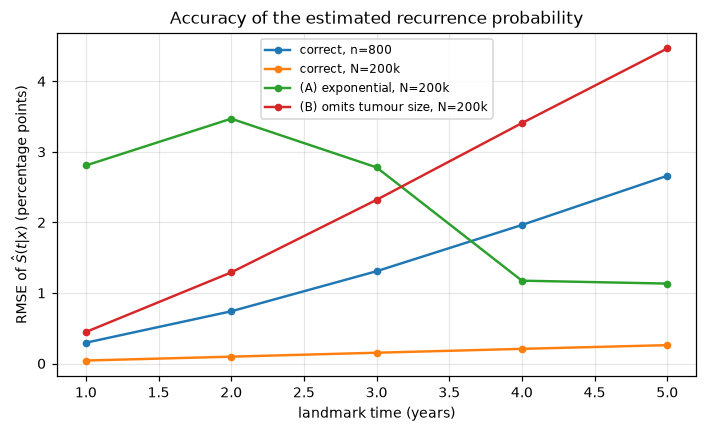

In [25]:
def predict_survival(fit: dict, df: pd.DataFrame, t: float) -> np.ndarray:
    '''Fitted S(t|x) for every row of `df`.'''
    beta = np.array([fit[c] for c in fit["covariates"]])
    lp = df[fit["covariates"]].to_numpy() @ beta
    return np.exp(-fit["lambda"] * t ** fit["gamma"] * np.exp(lp))


def true_survival(df: pd.DataFrame, dgp: DGP, t: float) -> np.ndarray:
    return np.exp(-dgp.lam * t ** dgp.gamma * np.exp(linear_predictor(df, dgp)))


landmarks = [1.0, 2.0, 3.0, 4.0, 5.0]
eval_set = big.sample(20_000, random_state=SEED)

rmse = pd.DataFrame(
    {name: {f"t={t:.0f}y": np.sqrt(np.mean((predict_survival(f, eval_set, t)
                                            - true_survival(eval_set, dgp, t)) ** 2))
            for t in landmarks}
     for name, f in fits.items()})

print("RMSE of the predicted recurrence-free probability (lower = better)\n")
print((rmse * 100).round(2).to_string())
print("\n(values are in percentage points of survival probability)")

fig, ax = plt.subplots(figsize=(6.5, 4))
for name in rmse.columns:
    ax.plot(landmarks, rmse[name].to_numpy() * 100, "o-", label=name, lw=1.6, ms=4)
ax.set(xlabel="landmark time (years)", ylabel="RMSE of $\\hat S(t|x)$ (percentage points)",
       title="Accuracy of the estimated recurrence probability")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 7. Export

Save one example cohort and the exact parameter values so Parts II and III are reproducible.

In [26]:
outdir = Path("data")
outdir.mkdir(exist_ok=True)

observed = ["age", "tumor_size", "chemo", "age_c10", "size_c", "time", "event"]
csv_path = outdir / "recurrence_sim_n800.csv"
data[observed].to_csv(csv_path, index=False)

params = asdict(dgp) | {"lambda_derived": dgp.lam,
                        "dropout_rate_derived": dgp.dropout_rate,
                        "covariates": COVARIATES, "seed": SEED,
                        "n": len(data), "time_unit": "years"}
json_path = outdir / "dgp_params.json"
json_path.write_text(json.dumps(params, indent=2))

print(f"wrote {csv_path}  ({len(data)} rows, {len(observed)} columns)")
print(f"wrote {json_path}")

wrote data/recurrence_sim_n800.csv  (800 rows, 7 columns)
wrote data/dgp_params.json


## 8. Summary for the report

| Component | Specification |
|---|---|
| Event | First confirmed breast cancer recurrence after completion of treatment |
| Population | ≈800 adult women treated for breast cancer, followed up to 5 years |
| True model | Weibull PH, $h(t\mid\mathbf{x})=\lambda\gamma t^{\gamma-1}e^{\mathbf{x}^{\top}\beta}$ |
| Shape | $\gamma = 1.6$ — increasing hazard, recurrence risk builds over the five years |
| Scale | $\lambda = -\log(0.75)/5^{1.6} \approx 0.0219$, i.e. a 25% baseline 5-year recurrence risk |
| $x_1$ age | $\mathcal{N}(60,12^2)$ truncated to $[30,85]$; $\beta_1 = -0.15$ per 10 y (HR 0.86) |
| $x_2$ tumour size | $\mathcal{N}(30,8^2)$ truncated to $[5,60]$ mm; $\beta_2 = +0.03$ per mm (HR 1.03) |
| $x_3$ chemotherapy | $\operatorname{logit}P = -2.0+0.06\,x_2$ — **by indication, not randomised**; $\beta_3 = -0.50$ (HR 0.61) |
| Censoring | Administrative at $\tau = 5$ y + independent loss to follow-up $\mathrm{Exp}(0.0325)$ (15% by 5 y) |
| Observed data | $Y_i = \min(T_i, C_i, 5)$, $\delta_i = \mathbb{1}\{T_i \le \min(C_i, 5)\}$ |
| Sample size | $n = 800$ per replicate, $R = 2000$ replicates |

**Research question.** How accurately can a parametric survival model estimate the probability of
breast cancer recurrence over time based on routinely recorded patient and clinical characteristics?

**Candidate incorrect analyses for Part II** (both already implemented in `fit_weibull_ph`):

* **(A)** Fit an **exponential** model ($\gamma \equiv 1$) when the truth is Weibull with
  $\gamma = 1.6$ — the constant-hazard assumption distorts $\hat S(t\mid\mathbf{x})$, most severely
  at the ends of the follow-up window.
* **(B)** **Omit tumour size** — because chemotherapy is allocated by indication, this leaves the
  treatment effect confounded and biased towards the null (HR $0.66$ instead of $0.61$; a fully
  crude comparison gives $0.68$, masking ~23% of the benefit), and it degrades
  $\hat S(t\mid\mathbf{x})$ increasingly at later landmark times.

**Next step.** `2_simulation_study.ipynb`: wrap `generate_dataset` and `fit_weibull_ph` in a loop
over $R = 2000$ replicates; store $\hat\beta$, $\hat\gamma$ and $\hat S(t\mid\mathbf{x})$ at the
landmark times under the correct and both incorrect analyses; report bias, empirical SE, MSE and
confidence-interval coverage.